In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression  # Corrected import statement
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set(style="whitegrid")
print("ALL LIBRARIES IMPORTED SUCESSFULLY")

ALL LIBRARIES IMPORTED SUCESSFULLY


Load and preview the dataset 

In [23]:
data=pd.read_csv("retail_marketing_sales.csv")
print(f"Datasetloaded: {data.shape[0]} rows x {data.shape[1]} columns")
data.head(10)

Datasetloaded: 150 rows x 7 columns


,Store_ID,City,Store_Area_sqft,Marketing_Spend_Lakhs,No_of_Promotions,Avg_Footfall_per_Day,Monthly_Sales_Lakhs
0,STR001,Mumbai,914,0.72,11,185,15.06
1,STR002,Hyderabad,2656,5.48,9,419,28.83
2,STR003,Bangalore,884,7.12,12,471,29.42
3,STR004,Hyderabad,1903,4.56,8,313,17.28
4,STR005,Pune,1201,1.78,8,244,8.99
5,STR006,Bangalore,2848,3.65,9,288,20.06
6,STR007,Bangalore,1943,6.11,4,374,31.45
7,STR008,Mumbai,1942,9.44,4,608,28.85
8,STR009,Delhi,1653,9.93,8,642,46.07
9,STR010,Bangalore,1798,2.80,1,228,17.32


In [25]:
title = "DATA TYPES AND NON-NULL COUNTS"
print(f"\n{title}\n{'=' * len(title)}")
data.info()
title = "STATISTICS SUMMARY"
print(f"\n{title}\n{'=' * len(title)}")
data.describe().round(2)


DATA TYPES AND NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_ID               150 non-null    object 
 1   City                   150 non-null    object 
 2   Store_Area_sqft        150 non-null    int64  
 3   Marketing_Spend_Lakhs  150 non-null    float64
 4   No_of_Promotions       150 non-null    int64  
 5   Avg_Footfall_per_Day   150 non-null    int64  
 6   Monthly_Sales_Lakhs    150 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 8.3+ KB

STATISTICS SUMMARY


,Store_Area_sqft,Marketing_Spend_Lakhs,No_of_Promotions,Avg_Footfall_per_Day,Monthly_Sales_Lakhs
count,150.00,150.00,150.00,150.00,150.00
mean,1907.75,5.10,6.41,374.41,23.21
std,657.29,2.86,3.65,164.30,10.61
min,814.00,0.60,1.00,80.00,3.00
25%,1344.50,2.58,3.00,241.00,14.48
50%,1878.00,4.88,6.00,360.00,22.73
75%,2514.50,7.66,10.00,507.25,32.22
max,2998.00,9.93,12.00,711.00,47.13


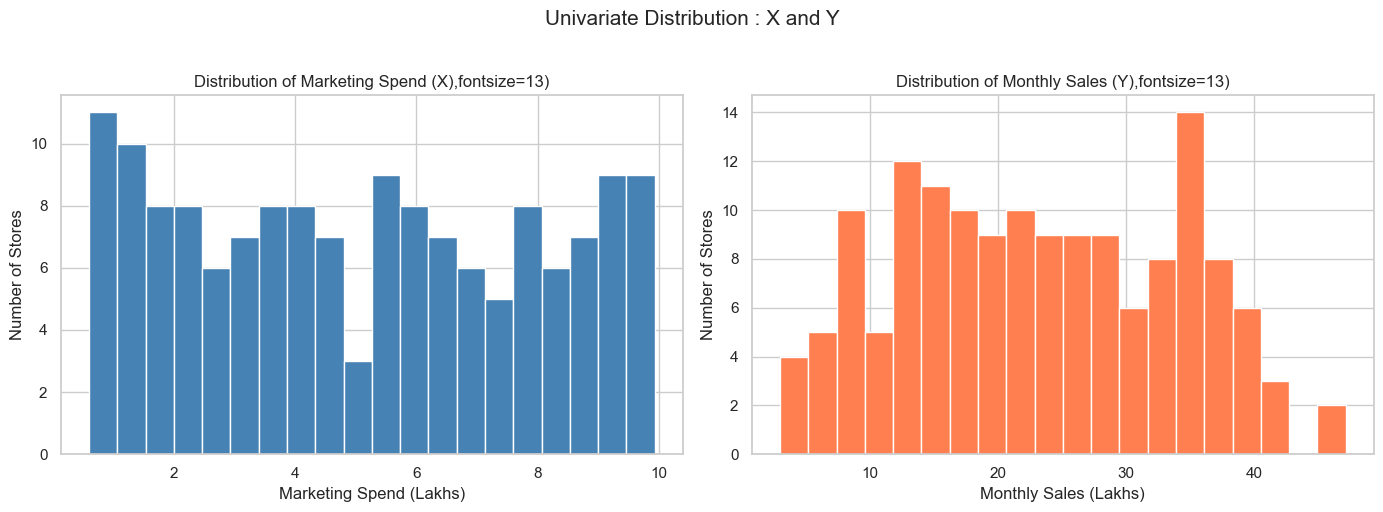

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(data["Marketing_Spend_Lakhs"], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution of Marketing Spend (X),fontsize=13)")
axes[0].set_xlabel("Marketing Spend (Lakhs)")
axes[0].set_ylabel("Number of Stores")

axes[1].hist(data["Monthly_Sales_Lakhs"], bins=20, color='coral', edgecolor='white')
axes[1].set_title("Distribution of Monthly Sales (Y),fontsize=13)")
axes[1].set_xlabel("Monthly Sales (Lakhs)")
axes[1].set_ylabel("Number of Stores")

plt.suptitle("Univariate Distribution : X and Y", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Key Insights from Distribution Analysis

### Marketing Spend (X) - Left Histogram:
- **Distribution Pattern**: Marketing spend shows a relatively **uniform distribution** across the range, indicating stores invest varying amounts in marketing
- **Range**: Marketing spend varies from approximately 0.6 to 10 Lakhs, with no single dominant spending level
- **Implication**: Stores have diverse marketing strategies, which is good for analyzing how different spending levels impact sales

### Monthly Sales (Y) - Right Histogram:
- **Distribution Pattern**: Monthly sales also shows a **fairly uniform distribution** with a slight right skew, suggesting most stores cluster around mid-range sales
- **Range**: Sales vary from 3 to 47 Lakhs per month, indicating significant variability in store performance
- **Central Tendency**: Most stores appear to generate monthly sales between 14-32 Lakhs

### Relationship Observations:
- Both variables show **good variability**, making them suitable for regression analysis
- No extreme outliers are evident that would require data cleaning
- The spread across both distributions suggests a **linear relationship is likely**, as stores with higher marketing spend tend to have higher sales
- This dataset is ideal for building a predictive Linear Regression model